# Decision Tree

In [ ]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

## Vectoriasation du dataset

In [27]:
df_train = ds['train'].to_pandas()
df_test = ds['test'].to_pandas()

In [28]:
X_train_text = df_train['func1'] + " [SEP] " + df_train['func2']
X_test_text = df_test['func1'] + " [SEP] " + df_test['func2']

y_train = df_train['label']
y_test = df_test['label']

In [29]:
del df_train, df_test

In [30]:
tfidf = TfidfVectorizer(max_features=100000, stop_words='english')

In [31]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

## Entrainement arbre de décision

In [32]:
clf = DecisionTreeClassifier(
    max_depth=50,       # Important pour éviter le surapprentissage et réduire le temps
    random_state=42,
    min_samples_leaf=5  # Lisse un peu le modèle
)

In [33]:
clf.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement terminé.


## Evaluation

In [34]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

## Interprétation des résultats

In [41]:
train_acc = clf.score(X_train, y_train)

print(f"Accuracy Train : {train_acc:.4f}")
print(f"Accuracy Test  : {acc:.4f}")

# Calcul de l'écart (Gap)
gap = train_acc - acc
print(f"Ecart : {gap:.4f}")

Accuracy Train : 0.9950
Accuracy Test  : 0.9598
Ecart : 0.0352


On constate une accuracy de 99% sur les données d'entrainment et 95% sur les données de test. Cela montre que notre modéle généralise bien.

In [39]:
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))


Rapport de classification :
              precision    recall  f1-score   support

       False       0.99      0.97      0.98    358596
        True       0.81      0.92      0.86     56820

    accuracy                           0.96    415416
   macro avg       0.90      0.94      0.92    415416
weighted avg       0.96      0.96      0.96    415416



On constate un recall de 92%, cela veut dire que notre modéle détecte 92% des clones présents. Le pont faible de notre modéle est la précision, seulement 81% ce qui veux dore que quand notre modéle dit détécter un clone, ils se trompe 1 fois sur 5 (19% de faux positifs).

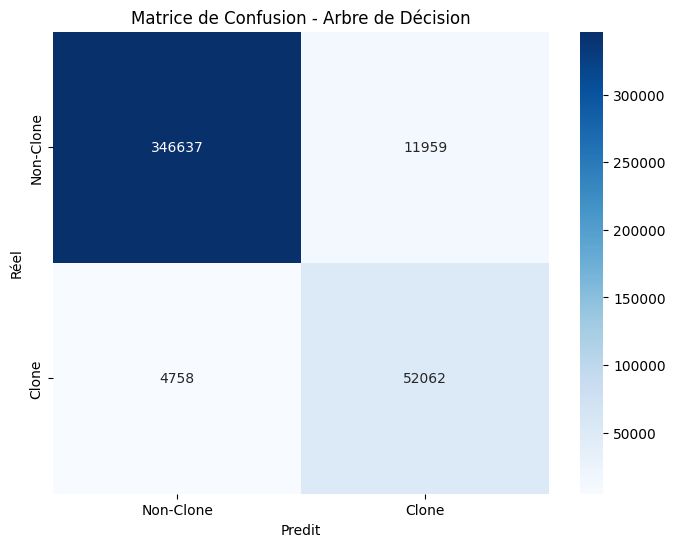

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcul de la matrice
cm = confusion_matrix(y_test, y_pred)

# Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Clone', 'Clone'], 
            yticklabels=['Non-Clone', 'Clone'])
plt.xlabel('Predit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion - Arbre de Décision')
plt.show()